In [1]:
# EDA Project

# Covid-19 Global Data Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/parmveer99solanki99-pixel/PROJECT_GRRAS/refs/heads/main/covid_19.csv"
df = pd.read_csv(url)

print("\nShape:",df.shape)

print("\nInformations:",df.info())

print("\nDecribation:",df.describe())

print("Data Type:")
print(df.dtypes)



Shape: (238, 9)
<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     238 non-null    str    
 1   continent   236 non-null    str    
 2   population  229 non-null    float64
 3   day         238 non-null    str    
 4   time        238 non-null    str    
 5   Cases       238 non-null    int64  
 6   Recovered   190 non-null    float64
 7   Deaths      233 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 16.9 KB

Informations: None

Decribation:          population         Cases     Recovered        Deaths         Tests
count  2.290000e+02  2.380000e+02  1.900000e+02  2.330000e+02  2.130000e+02
mean   3.469404e+07  8.883449e+06  1.006214e+07  9.026621e+04  3.298829e+07
std    1.386374e+08  5.193031e+07  5.555519e+07  5.163434e+05  1.198779e+08
min    7.990000e+02  9.000000e+00  2.00000

In [2]:

# Data Cleaning
# Handle Missing Values
print("\nMissing Values:")
print(df.isnull().sum())
print(df.dropna(inplace = True))


# Remove duplicate 
print("\nDuplicates:")
print(df.duplicated().sum())
print(df.drop_duplicates())


Missing Values:
country        0
continent      2
population     9
day            0
time           0
Cases          0
Recovered     48
Deaths         5
Tests         25
dtype: int64
None

Duplicates:
0
                   country      continent    population         day  \
2               Montserrat  North-America  4.965000e+03  2024-06-30   
7                    China           Asia  1.448471e+09  2024-06-30   
9    Saint-Pierre-Miquelon  North-America  5.759000e+03  2024-06-30   
14                Djibouti         Africa  1.016097e+06  2024-06-30   
15               Greenland  North-America  5.697300e+04  2024-06-30   
..                     ...            ...           ...         ...   
232                 Taiwan           Asia  2.388860e+07  2024-06-30   
233              Argentina  South-America  4.601023e+07  2024-06-30   
234            Netherlands         Europe  1.721145e+07  2024-06-30   
235                 Mexico  North-America  1.315628e+08  2024-06-30   
237             

In [3]:
# Cases
print("\nTotal Cases:")
print(df['Cases'].sum())

print("\n" + str(df['Cases'].describe()))

# Recovered
print("\nTotal Recovered:")
print(df['Recovered'].sum())

print("\n" + str(df['Recovered'].describe()))

# Deaths
print("\nTotal Deaths:")
print(df['Deaths'].sum())

print("\n" + str(df['Deaths'].describe()))


Total Cases:
567597278

count    1.690000e+02
mean     3.358564e+06
std      1.082718e+07
min      1.403000e+03
25%      3.613800e+04
50%      2.720100e+05
75%      1.734582e+06
max      1.118201e+08
Name: Cases, dtype: float64

Total Recovered:
555690895.0

count    1.690000e+02
mean     3.288112e+06
std      1.062387e+07
min      4.380000e+02
25%      3.233200e+04
50%      2.588880e+05
75%      1.724921e+06
max      1.098144e+08
Name: Recovered, dtype: float64

Total Deaths:
5809722.0

count    1.690000e+02
mean     3.437705e+04
std      1.199160e+05
min      1.000000e+00
25%      3.160000e+02
50%      3.165000e+03
75%      1.805700e+04
max      1.219487e+06
Name: Deaths, dtype: float64


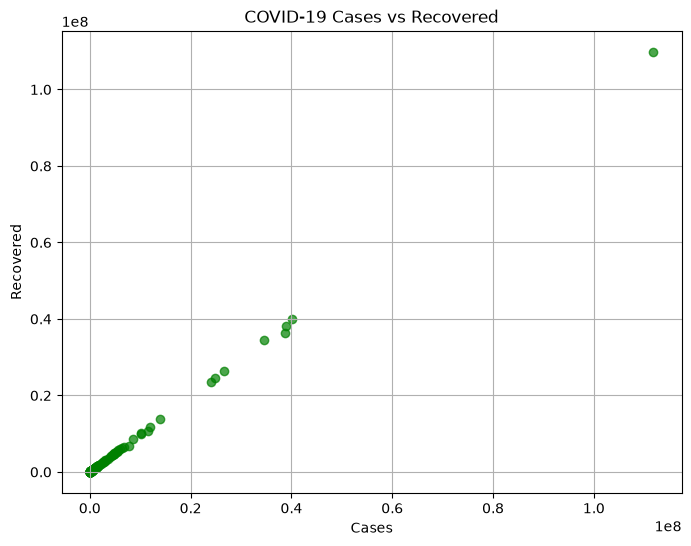

In [4]:

# Cases Vs Recovered
plt.figure(figsize=(8,6))

plt.scatter(df['Cases'], df['Recovered'], color='green', alpha=0.7)

plt.xlabel("Cases")
plt.ylabel("Recovered")
plt.title("COVID-19 Cases vs Recovered")
plt.grid(True)

plt.show()

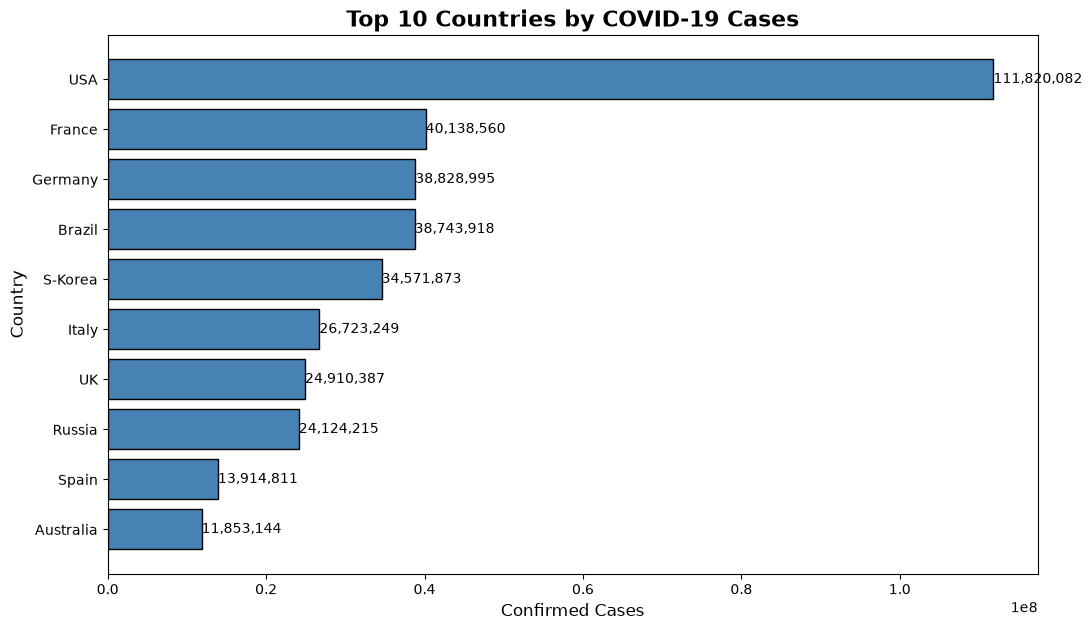

In [5]:

# Select Top 10 countries
top10 = df.nlargest(10, 'Cases')

# Sort for horizontal bar chart
top10 = top10.sort_values(by='Cases')

plt.figure(figsize=(12, 7))

plt.barh(top10['country'], top10['Cases'],
         color='steelblue', edgecolor='black')

plt.xlabel("Confirmed Cases", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.title("Top 10 Countries by COVID-19 Cases", fontsize=16, fontweight='bold')

# Display values on bars
for i, v in enumerate(top10['Cases']):
    plt.text(v, i, f'{v:,}', va='center', fontsize=10)

plt.show()

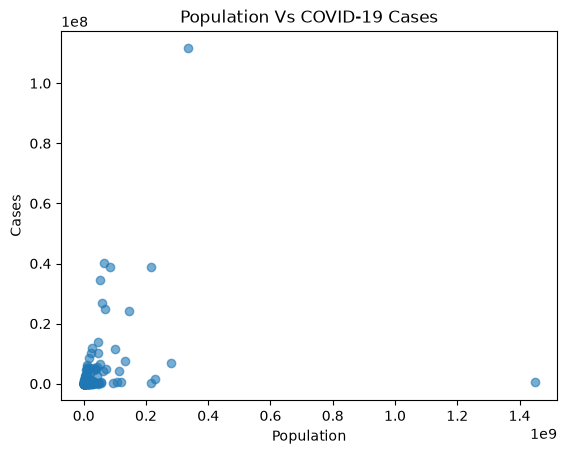

In [6]:
# Population Vs Cases

plt.Figure(figsize = (15, 8))
plt.scatter(df['population'], df['Cases'], alpha = 0.6)

plt.xlabel("Population")
plt.ylabel("Cases")
plt.title("Population Vs COVID-19 Cases")
plt.show()

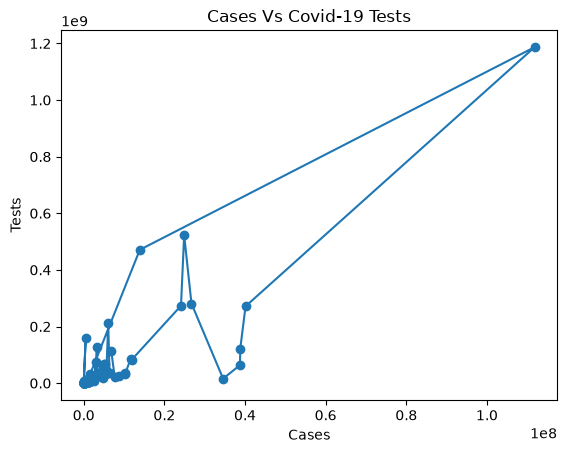

In [7]:
# Cases Vs Tests

plt.Figure(figsize = (20, 8))
plt.plot(df['Cases'], df['Tests'], marker = 'o')

plt.xlabel("Cases")
plt.ylabel("Tests")
plt.title("Cases Vs Covid-19 Tests")
plt.show()

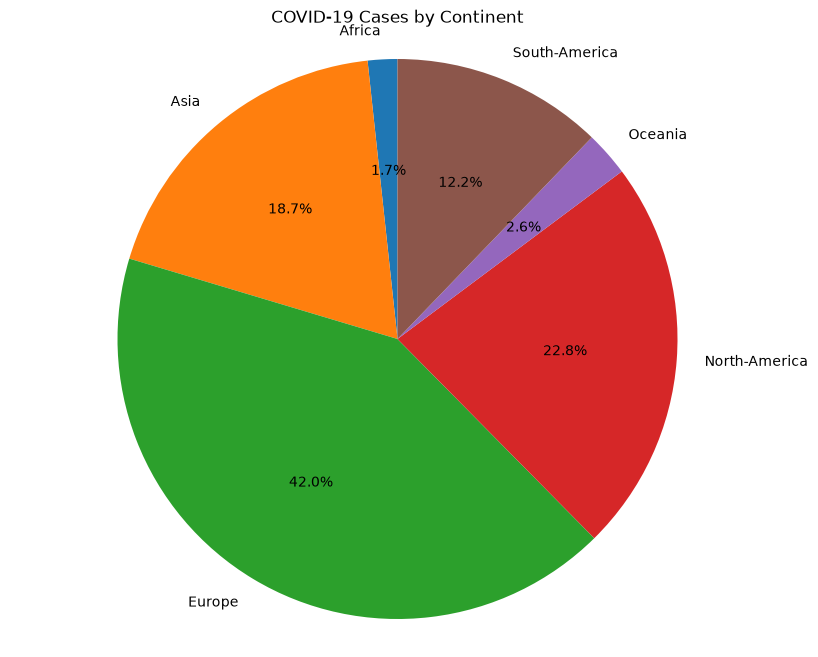

In [8]:
# Continent Analysis

# Group by continent
continent_cases = df.groupby('continent')['Cases'].sum()

plt.figure(figsize=(10,8))

plt.pie(
    continent_cases,
    labels=continent_cases.index,
    autopct='%1.1f%%',
    startangle=90,
)

plt.title("COVID-19 Cases by Continent")
plt.axis('equal')  # Makes the pie chart circular

plt.show()

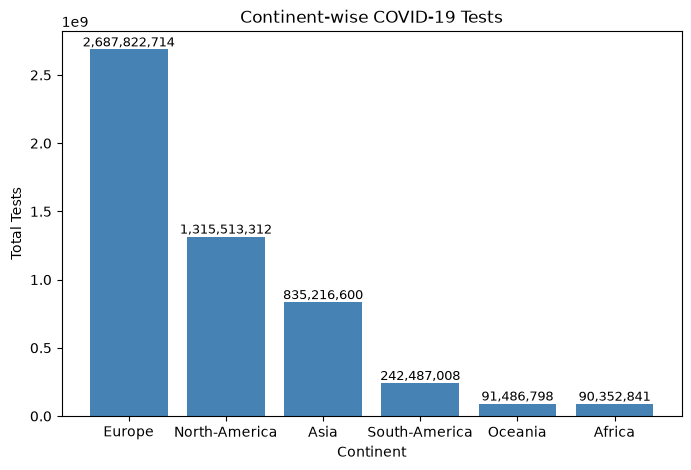

In [9]:
# Continent-Wise Tests
# Remove 'All'
continent_df = df[df['continent'] != 'All']

# Total tests by continent
continent_tests = (
    continent_df.groupby('continent')['Tests']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    continent_tests.index,
    continent_tests.values,
    color='steelblue'
)

plt.title("Continent-wise COVID-19 Tests")
plt.xlabel("Continent")
plt.ylabel("Total Tests")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,.0f}",
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.show()